In [1]:
import sys
print(sys.path)

sys.path.insert(1, '/home/andreas/prj_AH/analysis_buckle/') ## this is the path to the pybuckle package.
                                                            ## only necessary if the location is not in your
                                                            ## python path
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import MDAnalysis as mda
from MDAnalysis import transformations
import nglview as nv

from pybuckle.fourier import *
from pybuckle.solveBVP import BuckleBVPSolver, makeTables
from pybuckle.getshapecoeff import BucklesShapeFCoeff
from pybuckle.fitshape import FitShape, prefit_fun
from pybuckle.misc import min_image_dist, rotateVec

SMALL_SIZE = 16
MEDIUM_SIZE = 20 
BIGGER_SIZE = 24

plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)

['/home/andreas/prj_AH/buckle_atr20_x_pw_rep1', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '', '/home/andreas/.local/lib/python3.8/site-packages', '/usr/local/lib/python3.8/dist-packages', '/usr/local/lib/python3.8/dist-packages/memsurfer-1.1.0-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/vtk-9.2.0rc2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/numpy-1.23.2-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/wslink-1.7.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/matplotlib-3.5.3-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/aiohttp-3.8.1-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/kiwisolver-1.4.4-py3.8-linux-x86_64.egg', '/usr/local/lib/python3.8/dist-packages/fonttools-4.35.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/cycler-0.11.0-py3.8.egg', '/usr/local/lib/python3.8/dist-packages/yarl-1.8.1-py3.8-linux-x86_64.egg', '/usr/local/lib/p

In [2]:
%load_ext autoreload
#%load_ext line_profiler

%autoreload 2

In [3]:
basedir = '/home/andreas/prj_AH/NAME/repREP/' 
workdir = basedir
umbdir = workdir + 'UMBRELLA/'

# this gives L0, i.e., the membrane length. As a large membrane will have undulations, it can be useful to
# suppress undulations with position restraints in z-direction
#membraneOnly_box_x = np.loadtxt(basedir + 'membraneOnly/NPT/box-x.xvg', skiprows=24)
u = mda.Universe(workdir + 'pull.tpr', workdir + 'pull_reduced.xtc' )

lx = u.dimensions[0] / 10
ly = u.dimensions[1] / 10
lz = u.dimensions[2] / 10
print(lx, ly, lz)

#L0 = np.mean(membraneOnly_box_x[:,1])
L0 = 30
print('L0 = %f' %L0)
Lx = lx
g = Lx / L0
print(g)

21.0 10.0 22.20881042480469
L0 = 30.000000
0.7


In [4]:
plt.rcParams['figure.figsize'] = 14, 14 #/ aspect_ratio
plt.rcParams['legend.fontsize'] = SMALL_SIZE

In [5]:
#protein = u.select_atoms('moltype Protein')
protein = u.select_atoms('moltype Protein_A')
protein

<AtomGroup with 60 atoms>

In [6]:
po4 = u.select_atoms('name PO4')

Look at pull trajectory with nglview. This is just an easy way to make sure that the whole range you want to sample is covered and that the molecule, that is pulled, is attached to the membrane everywhere in this range.  Obviously this part can be done outside the notebook, with any visualization software you like. In this case we were only interested in the positively curved region. Before the pulling simulation, I arange the membrane inside the simulation box such that s = -0.25 is at x = 0 and s = 0.75 is at x = x_max. (Like in Figure 3 in the paper.) Everything is tested only in this configuration.

In [7]:
view = nv.show_mdanalysis(protein)
#view.clear()

view.add_trajectory(po4)
view.add_unitcell()
view.control.rotate(
   mda.lib.transformations.quaternion_from_euler(
       -np.pi/2, np.pi, 0, 'rzyz').tolist())
view.control.zoom(.6)
view.camera = 'orthographic'
view._remote_call("setSize", target="Widget", args=["1000px", "1000px"])

view.add_ball_and_stick('protein' )


In [8]:
view

NGLWidget(max_frame=370)

In [9]:
fitter = FitShape(Lx, g) # This instance of the FitShape class takes care of the fitting.
outsideshaper = BucklesShapeFCoeff()

In [10]:
curve_atoms = u.select_atoms('name C4A C4B')
len(curve_atoms)

1610

In [11]:
len(u.trajectory)

371

In [12]:
frame_stride = 1 # the example trajectory has a large stride already, for reduction of size 
start_frame = 0 # len(gro.trajectory) * 1 // 4
print(start_frame)

nFrames = (len(u.trajectory) - start_frame) // frame_stride #+ 1
print(nFrames)

0
371


In [13]:
## estimated time, with roughly 3 s per frame
t_est = 3 * nFrames / 3600
print('estimated time = %f h, or %f min' %(t_est, t_est*60))

estimated time = 0.309167 h, or 18.550000 min


Actual fitting of the membrane shape and projection onto s of the probe molecules is done in the next step.

In [14]:
fit_scores = np.zeros(nFrames)
minim_g_out_all = np.zeros((nFrames, 3 + len(curve_atoms)))
axAllFrames = np.zeros((nFrames, 7))
azAllFrames = np.zeros((nFrames, 8))
u.trajectory[start_frame]

s_protein = np.zeros(nFrames)
protein_coords = np.zeros((nFrames, 3))

for i, frame in enumerate(u.trajectory[start_frame::frame_stride]):
    print(frame.time)
    curve_atoms = u.select_atoms('name C4A C4B')
    po4_atoms = u.select_atoms('name PO4')
    po4_coords = po4_atoms.positions / 10
    #protein = u.select_atoms('moltype Protein')
    protein = u.select_atoms('moltype Protein_A')

    x = curve_atoms.positions[:,0] / 10
    z = curve_atoms.positions[:,2] / 10
    xz_combined = np.column_stack([x, z])
    
    fitter.do_prefit(xz_combined)
    minim_g_out, ax_at_fitted_g, az_at_fitted_g = fitter.fit(xz_combined)
    minim_g_out_all[i,:] = minim_g_out.x
    axAllFrames[i,:] = ax_at_fitted_g
    azAllFrames[i,:] = az_at_fitted_g
    fit_scores[i] = minim_g_out.fun
    
    x0 = minim_g_out.x[0]
    z0 = minim_g_out.x[1]
    
    s_plot = np.linspace(fitter.s_min, fitter.s_max, int(1e4)+1)
    X_plot = fs_x(s_plot, *ax_at_fitted_g) * lx
    Z_plot = fs_z(s_plot, *az_at_fitted_g) * lx  
    
    protein_com = protein.center_of_mass() / 10
    protein_coords[i,:] = protein_com
    
    #dx_loop = calcDist_min_image(x0 + X_plot, loop_com[0], lx)
    dx_protein = min_image_dist(x0 + X_plot, protein_com[0], lx)
    projected_s_indices_protein = np.argmin((dx_protein)**2 +
                                       (z0 + Z_plot - protein_com[2])**2, axis=0 )
    s_protein[i] = s_plot[projected_s_indices_protein].reshape(-1)

220000.0
221000.0
222000.0
223000.0
224000.0
225000.0
226000.0
227000.0
228000.0
229000.0
230000.0
231000.0
232000.0
233000.0
234000.0
235000.0
236000.0
237000.0
238000.0
239000.0
240000.0
241000.0
242000.0
243000.0
244000.0
245000.0
246000.0
247000.0
248000.0
249000.0
250000.0
251000.0
252000.0
253000.0
254000.0
255000.0
256000.0
257000.0
258000.0
259000.0
260000.0
261000.0
262000.0
263000.0
264000.0
265000.0
266000.0
267000.0
268000.0
269000.0
270000.0
271000.0
272000.0
273000.0
274000.0
275000.0
276000.0
277000.0
278000.0
279000.0
280000.0
281000.0
282000.0
283000.0
284000.0
285000.0
286000.0
287000.0
288000.0
289000.0
290000.0
291000.0
292000.0
293000.0
294000.0
295000.0
296000.0
297000.0
298000.0
299000.0
300000.0
301000.0
302000.0
303000.0
304000.0
305000.0
306000.0
307000.0
308000.0
309000.0
310000.0
311000.0
312000.0
313000.0
314000.0
315000.0
316000.0
317000.0
318000.0
319000.0
320000.0
321000.0
322000.0
323000.0
324000.0
325000.0
326000.0
327000.0
328000.0
329000.0
330000.0
3

In [15]:
x0_mean = np.mean(minim_g_out_all[:,0])
x0_std  = np.std(minim_g_out_all[:,0])

z0_mean = np.mean(minim_g_out_all[:,1])
z0_std  = np.std(minim_g_out_all[:,1])

g_mean = np.mean(minim_g_out_all[:,2])
g_std  = np.std(minim_g_out_all[:,2])

print(x0_mean, x0_std, x0_std / x0_mean)
print(z0_mean, z0_std, z0_std / z0_mean)
print(g_mean,  g_std,  g_std  / g_mean)

6.41130114262935 0.033904727742933835 0.005288275653985129
6.703461813788994 0.033818283285041655 0.005044898326336041
0.7215375786905556 0.0025740371760581723 0.003567433287022317


In [16]:
#s_plot = np.linspace(fitter.s_min, fitter.s_max, 201)
fitted_shape_coeff = outsideshaper.get_FCoeff(g_mean, Lx,
                                     s=(s_plot))

ax_at_fitted_g = fitted_shape_coeff[12]
az_at_fitted_g = fitted_shape_coeff[13]
X = fitted_shape_coeff[0]
Z = fitted_shape_coeff[1]


Save fit results to a hdf5 file. This will be used in the analysis.

In [17]:
hf = h5py.File(umbdir + 'shape_data.h5', 'w')

hf.create_dataset('minim_g_out_all', data=minim_g_out_all)
shape_grp = hf.create_group('shape_coeff')
shape_grp.create_dataset('g_mean', data=g_mean)
shape_grp.create_dataset('Lx', data=Lx)
shape_grp.create_dataset('s_plot', data=s_plot)

hf.close()

In [18]:
solver = BuckleBVPSolver(g_mean, 10001)
s01 = np.linspace(0, 1, 10001)

Select the range of s values, i.e., the reaction coordinate and number of umbrella windows

In [19]:
s_window = np.linspace(0.0, 0.5, 64) # In this case, we were only interested in the positively curved region 
s_window

array([0.        , 0.00793651, 0.01587302, 0.02380952, 0.03174603,
       0.03968254, 0.04761905, 0.05555556, 0.06349206, 0.07142857,
       0.07936508, 0.08730159, 0.0952381 , 0.1031746 , 0.11111111,
       0.11904762, 0.12698413, 0.13492063, 0.14285714, 0.15079365,
       0.15873016, 0.16666667, 0.17460317, 0.18253968, 0.19047619,
       0.1984127 , 0.20634921, 0.21428571, 0.22222222, 0.23015873,
       0.23809524, 0.24603175, 0.25396825, 0.26190476, 0.26984127,
       0.27777778, 0.28571429, 0.29365079, 0.3015873 , 0.30952381,
       0.31746032, 0.32539683, 0.33333333, 0.34126984, 0.34920635,
       0.35714286, 0.36507937, 0.37301587, 0.38095238, 0.38888889,
       0.3968254 , 0.4047619 , 0.41269841, 0.42063492, 0.42857143,
       0.43650794, 0.44444444, 0.45238095, 0.46031746, 0.46825397,
       0.47619048, 0.48412698, 0.49206349, 0.5       ])

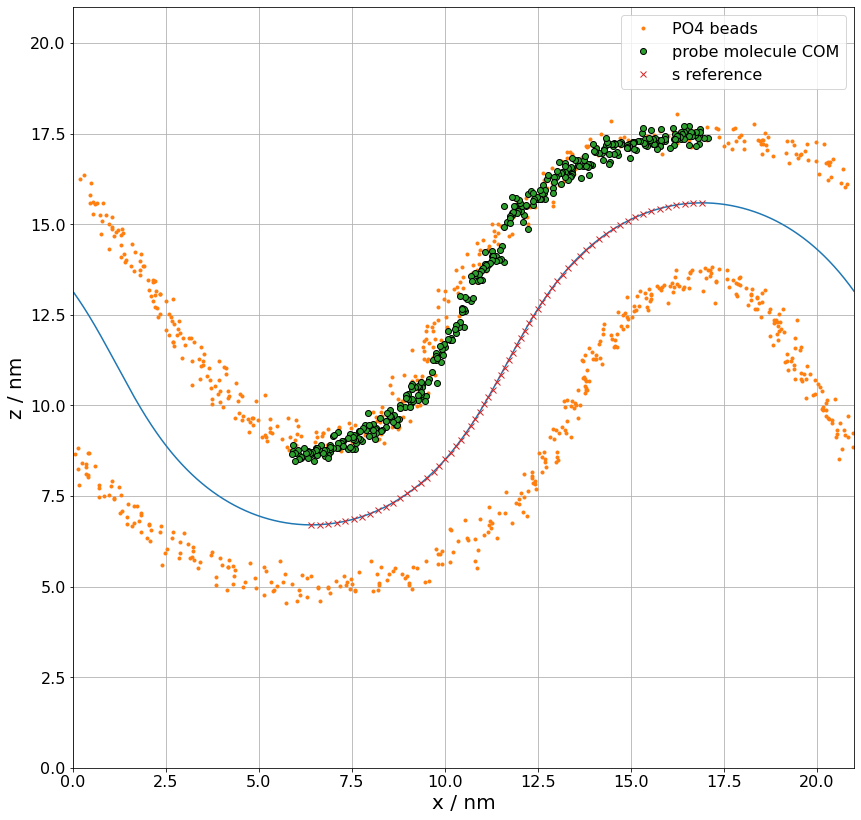

In [20]:
colors = ["C0", "C1", 'C2', 'C3', "C4", 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']
fig, ax = plt.subplots(figsize=(14, 14))


plt.plot(x0_mean + X, z0_mean + Z)
plt.plot(po4_coords[:,0], po4_coords[:,2], '.', label='PO4 beads')


plt.plot(protein_coords[:,0], protein_coords[:,2], 'o', markeredgecolor=(0, 0, 0, 1),
        label='probe molecule COM')


plt.plot(x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx,
         z0_mean + fs_z(s_window, *az_at_fitted_g) * lx, 'x',
        label='s reference')
 

plt.xlabel('x / nm')
plt.ylabel('z / nm')
plt.xlim(0, lx)
plt.ylim(0, lx)

plt.legend()

plt.grid()
plt.show()

In [21]:
ds = np.abs(s_protein.reshape(-1,1) - s_window.reshape(1,-1))

In [22]:
# this selects the 
s_protein_indices_min = np.argmin(ds, axis=0)
s_protein_indices_min

array([352, 351, 347, 341, 336, 337, 327, 332, 330, 322, 316, 310, 309,
       301, 295, 291, 288, 279, 286, 275, 274, 264, 267, 250, 252, 248,
       246, 246, 239, 236, 234, 228, 226, 222, 220, 221, 214, 213, 211,
       208, 199, 189, 187, 183, 182, 180, 169, 165, 150, 145, 137, 136,
       108, 107,  97,  87,  77,  70,  58,  56,  34,  28,  12,   1])

In [23]:
# translate indices to frame indices of the trajectory (if stride > 1 and start frame > 0)
np.sort(s_protein_indices_min * frame_stride + start_frame)

array([  1,  12,  28,  34,  56,  58,  70,  77,  87,  97, 107, 108, 136,
       137, 145, 150, 165, 169, 180, 182, 183, 187, 189, 199, 208, 211,
       213, 214, 220, 221, 222, 226, 228, 234, 236, 239, 246, 246, 248,
       250, 252, 264, 267, 274, 275, 279, 286, 288, 291, 295, 301, 309,
       310, 316, 322, 327, 330, 332, 336, 337, 341, 347, 351, 352])

In [24]:
for frame in u.trajectory[s_protein_indices_min * frame_stride + start_frame]:
    print(frame.time)

572000.0
571000.0
567000.0
561000.0
556000.0
557000.0
547000.0
552000.0
550000.0
542000.0
536000.0
530000.0
529000.0
521000.0
515000.0
511000.0
508000.0
499000.0
506000.0
495000.0
494000.0
484000.0
487000.0
470000.0
472000.0
468000.0
466000.0
466000.0
459000.0
456000.0
454000.0
448000.0
446000.0
442000.0
440000.0
441000.0
434000.0
433000.0
431000.0
428000.0
419000.0
409000.0
407000.0
403000.0
402000.0
400000.0
389000.0
385000.0
370000.0
365000.0
357000.0
356000.0
328000.0
327000.0
317000.0
307000.0
297000.0
290000.0
278000.0
276000.0
254000.0
248000.0
232000.0
221000.0


Calculate tangents and normal vectors

In [25]:
tangents = np.zeros((s_window.shape[0], 3)) 
for i in range(s_window.shape[0]):
    idx = np.argmin(np.abs(s01 - s_window[i]))
    s_tang = s01[idx]
    theta_i = solver.thetaSol_shifted[idx]
    tangents[i,:] = rotateVec(np.array([1, 0, 0]), theta_i)
    


In [26]:
normals = np.zeros((s_window.shape[0], 3)) 
for i in range(s_window.shape[0]):
    idx = np.argmin(np.abs(s01 - s_window[i]))
    s_tang = s01[idx]
    theta_i = solver.thetaSol_shifted[idx] + np.pi / 2
    normals[i,:] = rotateVec(np.array([1, 0, 0]), theta_i)

Plot tangents and probe molecule COM at selected frames

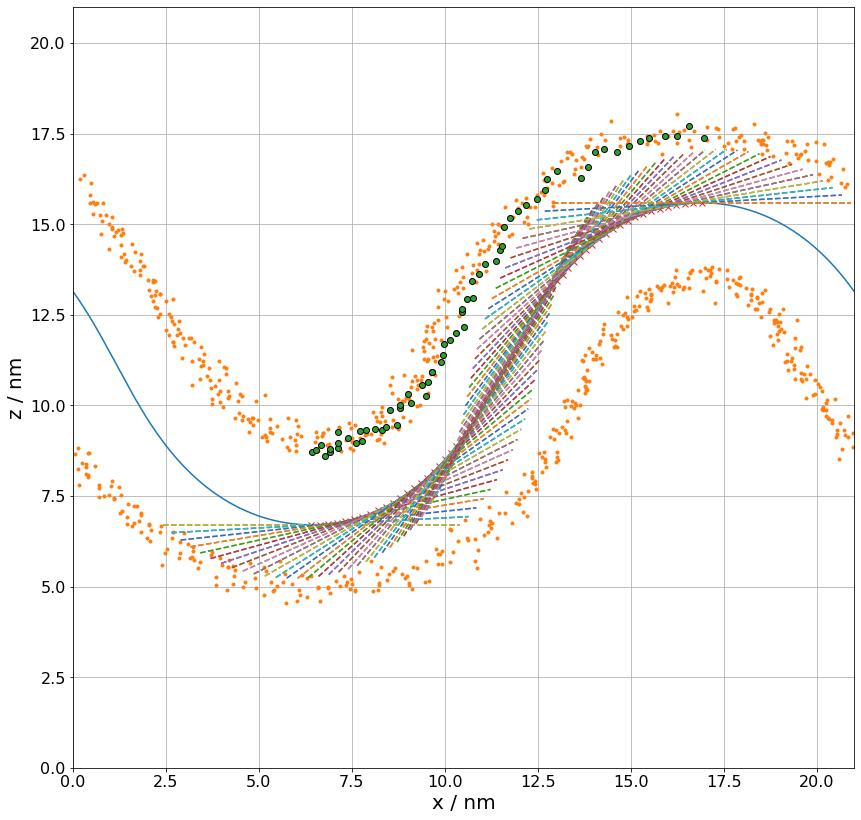

In [27]:
colors = ["C0", "C1", 'C2', 'C3', "C4", 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']
fig, ax = plt.subplots(figsize=(14, 14))


plt.plot(x0_mean + X, z0_mean + Z)
plt.plot(po4_coords[:,0], po4_coords[:,2], '.')


plt.plot(protein_coords[s_protein_indices_min,0], 
         protein_coords[s_protein_indices_min,2], 
         'o', 
         markeredgecolor=(0, 0, 0, 1))

plt.plot(x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx,
         z0_mean + fs_z(s_window, *az_at_fitted_g) * lx, 'x')

for i in range(0, s_window.shape[0], 1):
    x_win = fs_x(s_window, *ax_at_fitted_g) * lx
    z_win = fs_z(s_window, *az_at_fitted_g) * lx
    plt.plot([x0_mean + x_win[i] - 4 * tangents[i,0], 
              x0_mean + x_win[i] + 4 * tangents[i,0]],
             [z0_mean + z_win[i] - 4 * tangents[i,2],
              z0_mean + z_win[i] + 4 * tangents[i,2]], '--')
    
for i in range(0, s_window.shape[0], 1):
    x_win = fs_x(s_window, *ax_at_fitted_g) * lx
    z_win = fs_z(s_window, *az_at_fitted_g) * lx
    plt.plot([x0_mean + x_win[i] - 4 * tangents[i,0], 
              x0_mean + x_win[i] + 4 * tangents[i,0]],
             [z0_mean + z_win[i] - 4 * tangents[i,2],
              z0_mean + z_win[i] + 4 * tangents[i,2]], '--')
  
plt.xlabel('x / nm')
plt.ylabel('z / nm')
plt.xlim(0,  lx)
plt.ylim(0, lx)

plt.grid() 
plt.show()

In [28]:
delta_s_frames = np.zeros_like(s_protein[s_protein_indices_min])
delta_s_frames[1:] = np.flip(s_protein[s_protein_indices_min])[1:] - np.flip(s_protein[s_protein_indices_min])[:-1]
delta_s_frames

array([ 0.        , -0.00823191, -0.00859714, -0.00765677, -0.00826622,
       -0.00802926, -0.00764747, -0.00807983, -0.00754933, -0.00539584,
       -0.01034438, -0.00807815, -0.00818322, -0.00917037, -0.00562748,
       -0.00920267, -0.00838236, -0.00732954, -0.00782624, -0.00701324,
       -0.01238901, -0.00297421, -0.00995416, -0.00744992, -0.00831665,
       -0.00739222, -0.01312971, -0.00270989, -0.00940178, -0.00393169,
       -0.01009047, -0.00935264, -0.00714796, -0.00722988, -0.00888693,
       -0.00770947, -0.01303024,  0.        , -0.01097892, -0.00741202,
       -0.00766306, -0.00886998, -0.00797254, -0.00788056, -0.00319719,
       -0.01229835, -0.00674653, -0.01005209, -0.00706584, -0.00891961,
       -0.00888944, -0.00767745, -0.00542001, -0.0088843 , -0.01067089,
       -0.0058071 , -0.00796299, -0.0074937 , -0.00963306, -0.00574383,
       -0.00854262, -0.00663013, -0.00881215, -0.00567983])

In [29]:
frames = np.sort(s_protein_indices_min * frame_stride + start_frame)
frames

array([  1,  12,  28,  34,  56,  58,  70,  77,  87,  97, 107, 108, 136,
       137, 145, 150, 165, 169, 180, 182, 183, 187, 189, 199, 208, 211,
       213, 214, 220, 221, 222, 226, 228, 234, 236, 239, 246, 246, 248,
       250, 252, 264, 267, 274, 275, 279, 286, 288, 291, 295, 301, 309,
       310, 316, 322, 327, 330, 332, 336, 337, 341, 347, 351, 352])

In [30]:
frame_data = np.column_stack((np.array(frames, dtype="int"), np.flip(s_protein[s_protein_indices_min]), delta_s_frames))
frame_info = pd.DataFrame(frame_data, columns=['frame', 's', 'ds'])
frame_info["frame"] = np.array(frames, dtype="int")
frame_info

,frame,s,ds
0,1,0.500839,0.000000
1,12,0.492607,-0.008232
2,28,0.484010,-0.008597
3,34,0.476354,-0.007657
4,56,0.468087,-0.008266
...,...,...,...
59,337,0.031892,-0.005744
60,341,0.023349,-0.008543
61,347,0.016719,-0.006630
62,351,0.007907,-0.008812


In [31]:
frame_info.to_csv(umbdir + 'caught-output.dat', sep='\t', index=False, header=True)

In [32]:
def writeGRO(filename, u, frame_idx):
    file = open(filename, 'w')
    file.write('conf for umbrella sampling\n')
    file.write("%d\n" %u.trajectory.n_atoms)
    ts = u.trajectory[frame_idx]
    print(ts.time)
    for atom in u.atoms:
        file.write("%5d%-5s%5s%5d%8.3f%8.3f%8.3f\n" %(atom.resid,
             atom.resname, atom.name, atom.id, atom.position[0] / 10,
             atom.position[1] / 10, atom.position[2] / 10))

    file.write("%10.5f%10.5f%10.5f\n" %(ts.dimensions[0] / 10,
                                            ts.dimensions[1] / 10, 
                                            ts.dimensions[2] / 10,))
    file.close()

The dummy positions are the reference positions, that go into the mdp files.

In [33]:

dummy_positions = np.zeros((s_window.shape[0], 3))    

dummy_positions[:,0] = x0_mean + fs_x(s_window, *ax_at_fitted_g) * lx
dummy_positions[:,1] = ly / 2
dummy_positions[:,2] = z0_mean + fs_z(s_window, *az_at_fitted_g) * lx

In [34]:
dummy_positions = np.flip(dummy_positions, axis=0)

Write starting configurations.

In [35]:
frames = np.sort(s_protein_indices_min * frame_stride + start_frame)
for i, frame in enumerate(frames):
    print(i, frame)
    writeGRO(umbdir + 'conf%d.gro' %frame, u, frame,)

0 1
221000.0
1 12
232000.0
2 28
248000.0
3 34
254000.0
4 56
276000.0
5 58
278000.0
6 70
290000.0
7 77
297000.0
8 87
307000.0
9 97
317000.0
10 107
327000.0
11 108
328000.0
12 136
356000.0
13 137
357000.0
14 145
365000.0
15 150
370000.0
16 165
385000.0
17 169
389000.0
18 180
400000.0
19 182
402000.0
20 183
403000.0
21 187
407000.0
22 189
409000.0
23 199
419000.0
24 208
428000.0
25 211
431000.0
26 213
433000.0
27 214
434000.0
28 220
440000.0
29 221
441000.0
30 222
442000.0
31 226
446000.0
32 228
448000.0
33 234
454000.0
34 236
456000.0
35 239
459000.0
36 246
466000.0
37 246
466000.0
38 248
468000.0
39 250
470000.0
40 252
472000.0
41 264
484000.0
42 267
487000.0
43 274
494000.0
44 275
495000.0
45 279
499000.0
46 286
506000.0
47 288
508000.0
48 291
511000.0
49 295
515000.0
50 301
521000.0
51 309
529000.0
52 310
530000.0
53 316
536000.0
54 322
542000.0
55 327
547000.0
56 330
550000.0
57 332
552000.0
58 336
556000.0
59 337
557000.0
60 341
561000.0
61 347
567000.0
62 351
571000.0
63 352
572000

Read in base mdp file. Subsequently one mdp file for each umbrella window is generated with the corresponding pull directions and reference positions.

In [38]:
mdpFile = open(umbdir + 'umbrella_new-rf_base.mdp', 'r'  ) 
mdpLines = mdpFile.readlines()  

In [39]:
def writeMDP(mdpLines, filename, pull_coord1_vec, dummy_pos):
    file = open(filename, 'w')
    for line in mdpLines:
        if 'pull_coord1_vec' in line:
            print(line)
            newline = 'pull_coord1_vec         = %.5f 0.00000 %.5f\n' %(pull_coord1_vec[0], pull_coord1_vec[2])
            print(newline)
            file.write(newline)
        elif 'pull_coord1_origin' in line:
            print(line)
            newline = 'pull_coord1_origin      = %.3f %.3f %.3f\n' %(dummy_pos[0],
                                                                     dummy_pos[1],
                                                                     dummy_pos[2])
            print(newline)
            file.write(newline)
        else:
            file.write(line)
    
    

In [40]:
flipped_tangents = np.flip(tangents, axis=0) 
for i, frame in enumerate(frames):
    print(i, frame)
    writeMDP(mdpLines, umbdir + 'umbrella%d.mdp' %frame, flipped_tangents[i,:], dummy_positions[i,:])
#    writeMDP(mdpLines, umbdir + 'umbrella%d.mdp' %frame, tangents[i,:], dummy_positions[i,:])

0 1
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 1.00000 0.00000 0.00000

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.911 5.000 15.590

1 12
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.99846 0.00000 0.05543

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.680 5.000 15.583

2 28
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.99380 0.00000 0.11122

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.450 5.000 15.564

3 34
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.98618 0.00000 0.16565

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 16.222 5.000 15.532

4 56
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.97570 0.00000 0.21912

pull_coord1_origin	= 0.0 0.0 0.0

pull_coord1_origin      = 15.995 5.000 15.487

5 58
pull_coord1_vec         = 1.0 0.0 0.0

pull_coord1_vec         = 0.96230 0.00000 0.27199

pull_coord1_origin	= 0.0 0

The umbrella simulation setups are done. Below are examples for generating scripts for GROMPPing and submission to the server. I usually package several windows into one SLURM job. Obviously, this depends on the server hardware and the simulation system size.

In [ ]:
# done! 